#  Food Delivery Data Integration Project


This notebook describes how to:
1. Install and setup MySQL in Google Colab
2. Load data from CSV, JSON, and SQL files
3. Integrate data using left joins
4. Perform comprehensive analysis
5. Export results


---
##  Setup Environment
Install MySQL and required Python packages

In [2]:
# Install MySQL Server
!apt-get update
!apt-get install -y mysql-server

# Start MySQL service
!service mysql start

# Install Python MySQL connector
!pip install mysql-connector-python pandas numpy matplotlib seaborn -q

print(" MySQL installed")

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [3]:
# Set MySQL root password
!mysql -u root -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'password';"
!mysql -u root -ppassword -e "FLUSH PRIVILEGES;"

print("✓ MySQL configured")

mysql: [Warning] Using a password on the command line interface can be insecure.
✓ MySQL configured


---
##  Upload Data Files
Upload your three data files: orders.csv, users.json, restaurants.sql

In [4]:
from google.colab import files
import os

# Create data directory
!mkdir -p /content/data

print("Please upload your data files:")
print("1. orders.csv")
print("2. users.json")
print("3. restaurants.sql")
print("\nClick 'Choose Files' below and select all three files...")

uploaded = files.upload()

# Move files
for filename in uploaded.keys():
    !mv {filename} /content/data/

print("\n✓ Files uploaded successfully!")
!ls -lh /content/data/

Please upload your data files:
1. orders.csv
2. users.json
3. restaurants.sql

Click 'Choose Files' below and select all three files...


Saving restaurants.sql to restaurants.sql
Saving users.json to users.json
Saving orders.csv to orders.csv

✓ Files uploaded successfully!
total 924K
-rw-r--r-- 1 root root 561K Jan 31 11:30 orders.csv
-rw-r--r-- 1 root root  36K Jan 31 11:30 restaurants.sql
-rw-r--r-- 1 root root 323K Jan 31 11:30 users.json




```
`# This is formatted as code`
```

---
##  Create Database and Tables

In [5]:
import mysql.connector
import pandas as pd
import json
from datetime import datetime

# Database setup
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': 'password'
}

# Connect to MySQL
connection = mysql.connector.connect(**DB_CONFIG)
cursor = connection.cursor()

print("✓ Connected to MySQL")

✓ Connected to MySQL


In [11]:
# Create database
cursor.execute("DROP DATABASE IF EXISTS food_delivery_db")
cursor.execute("CREATE DATABASE food_delivery_db")
cursor.execute("USE food_delivery_db")

print("✓ Database created")

# Create orders table
cursor.execute("""
    CREATE TABLE orders (
        order_id INT PRIMARY KEY,
        user_id INT,
        restaurant_id INT,
        order_date VARCHAR(20),
        total_amount DECIMAL(10, 2),
        restaurant_name VARCHAR(255)
    )
""")

# Create users table
cursor.execute("""
    CREATE TABLE users (
        user_id INT PRIMARY KEY,
        name VARCHAR(100),
        city VARCHAR(100),
        membership VARCHAR(20)
    )
""")

# Create restaurants table
cursor.execute("""
    CREATE TABLE restaurants (
        restaurant_id INT PRIMARY KEY,
        restaurant_name VARCHAR(255),
        cuisine VARCHAR(50),
        rating DECIMAL(3, 2)
    )
""")

print("✓ Tables created")

# Show tables
cursor.execute("SHOW TABLES")
tables = cursor.fetchall()
print("\nTables in database:")
for table in tables:
    print(f"  - {table[0]}")

✓ Database created
✓ Tables created

Tables in database:
  - orders
  - restaurants
  - users


---
##  Load Data from Files

In [12]:
# Load CSV data (orders)
print("Loading orders from CSV...")
orders_df = pd.read_csv('/content/data/orders.csv')

# Insert orders
insert_query = """
    INSERT INTO orders
    (order_id, user_id, restaurant_id, order_date, total_amount, restaurant_name)
    VALUES (%s, %s, %s, %s, %s, %s)
"""

for index, row in orders_df.iterrows():
    cursor.execute(insert_query, tuple(row))
    if (index + 1) % 1000 == 0:
        print(f"  Loaded {index + 1} orders...")

connection.commit()
print(f"✓ Loaded {len(orders_df):,} orders")

Loading orders from CSV...
  Loaded 1000 orders...
  Loaded 2000 orders...
  Loaded 3000 orders...
  Loaded 4000 orders...
  Loaded 5000 orders...
  Loaded 6000 orders...
  Loaded 7000 orders...
  Loaded 8000 orders...
  Loaded 9000 orders...
  Loaded 10000 orders...
✓ Loaded 10,000 orders


In [13]:
# Load JSON data (users)

with open('/content/data/users.json', 'r') as f:
    users_data = json.load(f)

# Insert users
insert_query = """
    INSERT INTO users (user_id, name, city, membership)
    VALUES (%s, %s, %s, %s)
"""

for user in users_data:
    cursor.execute(insert_query, (
        user['user_id'],
        user['name'],
        user['city'],
        user['membership']
    ))

connection.commit()
print(f"✓ Loaded {len(users_data):,} users")

✓ Loaded 3,000 users


In [14]:
# Load SQL data (restaurants)
print("\nLoading restaurants from SQL file...")
with open('/content/data/restaurants.sql', 'r') as f:
    sql_script = f.read()

# Execute SQL statements
statements = sql_script.split(';')
count = 0

for statement in statements:
    statement = statement.strip()
    if statement and statement.upper().startswith('INSERT'):
        cursor.execute(statement)
        count += 1

connection.commit()

# Get actual count
cursor.execute("SELECT COUNT(*) FROM restaurants")
restaurant_count = cursor.fetchone()[0]
print(f"✓ Loaded {restaurant_count:,} restaurants")


Loading restaurants from SQL file...
✓ Loaded 500 restaurants


In [15]:
# Verify all data loaded
print("\n" + "="*50)
print("DATA VERIFICATION")
print("="*50)

cursor.execute("""
    SELECT 'orders' AS table_name, COUNT(*) AS count FROM orders
    UNION ALL
    SELECT 'users', COUNT(*) FROM users
    UNION ALL
    SELECT 'restaurants', COUNT(*) FROM restaurants
""")

results = cursor.fetchall()
for table, count in results:
    print(f"{table:15} {count:>10,} records")

print("="*50)


DATA VERIFICATION
orders              10,000 records
users                3,000 records
restaurants            500 records


---
##  Integrated Dataset

In [17]:


# Drop if exists
cursor.execute("DROP TABLE IF EXISTS final_food_delivery_dataset")

# Create integrated table
cursor.execute("""
    CREATE TABLE final_food_delivery_dataset AS
    SELECT
        -- Order Information
        o.order_id,
        o.order_date,
        o.total_amount,

        -- User Information
        o.user_id,
        u.name AS user_name,
        u.city,
        u.membership,

        -- Restaurant Information
        o.restaurant_id,
        r.restaurant_name,
        r.cuisine,
        r.rating AS restaurant_rating

    FROM orders o
    LEFT JOIN users u ON o.user_id = u.user_id
    LEFT JOIN restaurants r ON o.restaurant_id = r.restaurant_id
""")

connection.commit()

# Add indexes

cursor.execute("CREATE INDEX idx_order_date ON final_food_delivery_dataset(order_date)")
cursor.execute("CREATE INDEX idx_city ON final_food_delivery_dataset(city)")
cursor.execute("CREATE INDEX idx_cuisine ON final_food_delivery_dataset(cuisine)")
cursor.execute("CREATE INDEX idx_membership ON final_food_delivery_dataset(membership)")
connection.commit()

# Get count
cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset")
final_count = cursor.fetchone()[0]

print(f"\n✓ Integrated dataset created: {final_count:,} records")

# Data quality checks
print("\nData Quality Checks:")

cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset WHERE user_name IS NULL")
missing_users = cursor.fetchone()[0]
print(f"  Orders with missing user data: {missing_users}")

cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset WHERE restaurant_name IS NULL")
missing_restaurants = cursor.fetchone()[0]
print(f"  Orders with missing restaurant data: {missing_restaurants}")


✓ Integrated dataset created: 10,000 records

Data Quality Checks:
  Orders with missing user data: 0
  Orders with missing restaurant data: 0


In [18]:
# View sample data
print("\nSample of Integrated Dataset:")
cursor.execute("SELECT * FROM final_food_delivery_dataset LIMIT 5")
sample_data = cursor.fetchall()

# Get column names
cursor.execute("DESCRIBE final_food_delivery_dataset")
columns = [col[0] for col in cursor.fetchall()]

# Create DataFrame for display
sample_df = pd.DataFrame(sample_data, columns=columns)
display(sample_df)


Sample of Integrated Dataset:


,order_id,order_date,total_amount,user_id,user_name,city,membership,restaurant_id,restaurant_name,cuisine,restaurant_rating
0,1,18-02-2023,842.97,2508,User_2508,Hyderabad,Regular,450,Restaurant_450,Mexican,3.20
1,2,18-01-2023,546.68,2693,User_2693,Pune,Regular,309,Restaurant_309,Indian,4.50
2,3,15-07-2023,163.93,2084,User_2084,Chennai,Gold,107,Restaurant_107,Mexican,4.00
3,4,04-10-2023,1155.97,319,User_319,Bangalore,Gold,224,Restaurant_224,Chinese,4.80
4,5,25-12-2023,1321.91,1064,User_1064,Pune,Regular,293,Restaurant_293,Italian,3.00


In [33]:

print("\n" + "="*60)
print("GOLD MEMBERS REVENUE BY CITY")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        city,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS number_of_orders,
        COUNT(DISTINCT user_id) AS gold_members
    FROM final_food_delivery_dataset
    WHERE membership = 'Gold'
    GROUP BY city
    ORDER BY total_revenue DESC
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Rank':<6} {'City':<15} {'Revenue':<20} {'Orders':<10} {'Members':<10}")
print("-"*60)

for i, (city, revenue, orders, members) in enumerate(results, 1):
    if i == 1:
        print(f"   {i:<4} {city:<15} ₹{revenue:>16,.2f} {orders:>9,} {members:>9,}")
    else:
        print(f"   {i:<4} {city:<15} ₹{revenue:>16,.2f} {orders:>9,} {members:>9,}")

print("="*60)
print(f"\n ANSWER: {results[0][0]}")
print(f"   Total Revenue from Gold Members: ₹{results[0][1]:,.2f}")
print("="*60)


GOLD MEMBERS REVENUE BY CITY

Rank   City            Revenue              Orders     Members   
------------------------------------------------------------
   1    Chennai         ₹    1,080,909.79     1,337       386
   2    Pune            ₹    1,003,012.32     1,284       370
   3    Bangalore       ₹      994,702.59     1,254       354
   4    Hyderabad       ₹      896,740.19     1,112       320

 ANSWER: Chennai
   Total Revenue from Gold Members: ₹1,080,909.79


In [34]:

print("\n" + "="*60)
print(" AVERAGE ORDER VALUE BY CUISINE")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        cuisine,
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
    WHERE cuisine IS NOT NULL
    GROUP BY cuisine
    ORDER BY avg_order_value DESC
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Rank':<6} {'Cuisine':<15} {'Avg Order Value':<20} {'Orders':<10} {'Total Revenue':<15}")
print("-"*60)

for i, (cuisine, avg_value, orders, revenue) in enumerate(results, 1):
    if i == 1:
        print(f"   {i:<4} {cuisine:<15} ₹{avg_value:>16,.2f} {orders:>9,} ₹{revenue:>13,.2f}")
    else:
        print(f"   {i:<4} {cuisine:<15} ₹{avg_value:>16,.2f} {orders:>9,} ₹{revenue:>13,.2f}")

print("="*60)
print(f"\n ANSWER: {results[0][0]}")
print(f"   Average Order Value: ₹{results[0][1]:,.2f}")
print("="*60)


 AVERAGE ORDER VALUE BY CUISINE

Rank   Cuisine         Avg Order Value      Orders     Total Revenue  
------------------------------------------------------------
   1    Mexican         ₹          808.02     2,581 ₹ 2,085,503.09
   2    Italian         ₹          799.45     2,532 ₹ 2,024,203.80
   3    Indian          ₹          798.47     2,469 ₹ 1,971,412.58
   4    Chinese         ₹          798.39     2,418 ₹ 1,930,504.65

 ANSWER: Mexican
   Average Order Value: ₹808.02


In [35]:

print("\n" + "="*60)
print(" USERS WITH TOTAL ORDERS > ₹1000")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        COUNT(DISTINCT user_id) AS users_over_1000
    FROM (
        SELECT
            user_id,
            SUM(total_amount) AS total_spent
        FROM final_food_delivery_dataset
        GROUP BY user_id
        HAVING SUM(total_amount) > 1000
    ) AS high_spenders
""")

result = cursor.fetchone()
users_count = result[0]

print(f"\n Number of users with total orders > ₹1000: {users_count:,}")

# Show the range it falls into
print("\n" + "="*60)
print("ANSWER OPTIONS:")
print("="*60)

options = [
    ("< 500", 0, 500),
    ("500 – 1000", 500, 1000),
    ("1000 – 2000", 1000, 2000),
    ("> 2000", 2000, float('inf'))
]

for option, min_val, max_val in options:
    if min_val < users_count <= max_val:
        print(f" {option:<15} ← CORRECT ANSWER")
    else:
        print(f" {option:<15}")

print("="*60)
print(f"\n FINAL ANSWER: ", end="")
for option, min_val, max_val in options:
    if min_val < users_count <= max_val:
        print(option)
        break
print("="*60)

# Bonus: Show distribution
print("\n BONUS - User Spending Distribution:")
cursor.execute("""
    SELECT
        CASE
            WHEN total_spent <= 500 THEN '< ₹500'
            WHEN total_spent <= 1000 THEN '₹500 - ₹1000'
            WHEN total_spent <= 2000 THEN '₹1000 - ₹2000'
            WHEN total_spent <= 5000 THEN '₹2000 - ₹5000'
            ELSE '> ₹5000'
        END AS spending_range,
        COUNT(*) AS user_count
    FROM (
        SELECT
            user_id,
            SUM(total_amount) AS total_spent
        FROM final_food_delivery_dataset
        GROUP BY user_id
    ) AS user_totals
    GROUP BY spending_range
    ORDER BY MIN(total_spent)
""")

distribution = cursor.fetchall()
print(f"\n{'Spending Range':<20} {'Number of Users':<15}")
print("-"*35)
for range_name, count in distribution:
    print(f"{range_name:<20} {count:>14,}")
print("="*60)


 USERS WITH TOTAL ORDERS > ₹1000

 Number of users with total orders > ₹1000: 2,544

ANSWER OPTIONS:
 < 500          
 500 – 1000     
 1000 – 2000    
 > 2000          ← CORRECT ANSWER

 FINAL ANSWER: > 2000

 BONUS - User Spending Distribution:

Spending Range       Number of Users
-----------------------------------
< ₹500                          114
₹500 - ₹1000                    225
₹1000 - ₹2000                   699
₹2000 - ₹5000                 1,560
> ₹5000                         285


In [40]:


print("\n" + "="*60)
print(" REVENUE BY RESTAURANT RATING RANGE")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        CASE
            WHEN restaurant_rating >= 4.6 THEN '4.6 – 5.0'
            WHEN restaurant_rating >= 4.1 THEN '4.1 – 4.5'
            WHEN restaurant_rating >= 3.6 THEN '3.6 – 4.0'
            WHEN restaurant_rating >= 3.0 THEN '3.0 – 3.5'
            ELSE 'Below 3.0'
        END AS rating_range,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT restaurant_id) AS num_restaurants,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE restaurant_rating IS NOT NULL
    GROUP BY rating_range
    ORDER BY total_revenue DESC
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Rank':<6} {'Rating Range':<15} {'Total Revenue':<20} {'Orders':<10} {'Restaurants':<12}")
print("-"*75)

for i, (rating_range, revenue, orders, restaurants, avg_value) in enumerate(results, 1):
    if i == 1:
        print(f"   {i:<4} {rating_range:<15} ₹{revenue:>16,.2f} {orders:>9,} {restaurants:>11,}")
    else:
        print(f"   {i:<4} {rating_range:<15} ₹{revenue:>16,.2f} {orders:>9,} {restaurants:>11,}")

print("="*75)
print(f"\n ANSWER: {results[0][0]}")
print(f"   Total Revenue: ₹{results[0][1]:,.2f}")
print(f"   Number of Orders: {results[0][2]:,}")
print("="*75)




 REVENUE BY RESTAURANT RATING RANGE

Rank   Rating Range    Total Revenue        Orders     Restaurants 
---------------------------------------------------------------------------
   1    4.6 – 5.0       ₹    2,197,030.75     2,772         135
   2    3.0 – 3.5       ₹    2,136,772.70     2,679         133
   3    4.1 – 4.5       ₹    1,960,326.26     2,431         123
   4    3.6 – 4.0       ₹    1,717,494.41     2,118         109

 ANSWER: 4.6 – 5.0
   Total Revenue: ₹2,197,030.75
   Number of Orders: 2,772


In [39]:

print("\n" + "="*60)
print(" AVERAGE ORDER VALUE - GOLD MEMBERS BY CITY")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        city,
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS gold_members,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
    WHERE membership = 'Gold' AND city IS NOT NULL
    GROUP BY city
    ORDER BY avg_order_value DESC
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Rank':<6} {'City':<15} {'Avg Order Value':<20} {'Orders':<10} {'Members':<10}")
print("-"*70)

for i, (city, avg_value, orders, members, revenue) in enumerate(results, 1):
    if i == 1:
        print(f"   {i:<4} {city:<15} ₹{avg_value:>16,.2f} {orders:>9,} {members:>9,}")
    else:
        print(f"   {i:<4} {city:<15} ₹{avg_value:>16,.2f} {orders:>9,} {members:>9,}")

print("="*70)
print(f"\n ANSWER: {results[0][0]}")
print(f"   Average Order Value: ₹{results[0][1]:,.2f}")
print(f"   Total Orders: {results[0][2]:,}")
print("="*70)




 AVERAGE ORDER VALUE - GOLD MEMBERS BY CITY

Rank   City            Avg Order Value      Orders     Members   
----------------------------------------------------------------------
   1    Chennai         ₹          808.46     1,337       386
   2    Hyderabad       ₹          806.42     1,112       320
   3    Bangalore       ₹          793.22     1,254       354
   4    Pune            ₹          781.16     1,284       370

 ANSWER: Chennai
   Average Order Value: ₹808.46
   Total Orders: 1,337


In [41]:


print("\n" + "="*60)
print(" CUISINE ANALYSIS: Restaurants vs Revenue")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        cuisine,
        COUNT(DISTINCT restaurant_id) AS num_restaurants,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS total_orders,
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        ROUND(SUM(total_amount) / COUNT(DISTINCT restaurant_id), 2) AS revenue_per_restaurant
    FROM final_food_delivery_dataset
    WHERE cuisine IS NOT NULL
    GROUP BY cuisine
    ORDER BY num_restaurants ASC, total_revenue DESC
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Cuisine':<12} {'Restaurants':<13} {'Total Revenue':<18} {'Orders':<10} {'Revenue/Restaurant':<20}")
print("-"*90)

min_restaurants = results[0][1]
significant_threshold = sum([r[2] for r in results]) / len(results)  # Average revenue

for cuisine, restaurants, revenue, orders, avg_value, rev_per_rest in results:
    marker = ""
    if restaurants == min_restaurants and revenue > significant_threshold:
        marker = " "
    print(f"{marker}{cuisine:<12} {restaurants:>12,} ₹{revenue:>15,.2f} {orders:>9,} ₹{rev_per_rest:>17,.2f}")

print("="*90)

# Find the answer
print("\n ANALYSIS:")
print("="*60)

# Calculate what "significant" means
avg_revenue = sum([r[2] for r in results]) / len(results)
print(f"Average revenue across all cuisines: ₹{avg_revenue:,.2f}")
print(f"\nCuisines with LOWEST restaurant count:")

# Get cuisines with minimum restaurant count
min_rest_count = min([r[1] for r in results])
candidates = [(r[0], r[1], r[2]) for r in results if r[1] == min_rest_count]

print(f"Minimum restaurant count: {min_rest_count}")
print(f"\nCuisines with {min_rest_count} restaurants:")
for cuisine, rest_count, revenue in candidates:
    is_significant = " SIGNIFICANT" if revenue > avg_revenue else " Not significant"
    print(f"  • {cuisine:<12} - ₹{revenue:>12,.2f} - {is_significant}")

print("="*60)

# Determine the answer
answer_cuisine = None
for cuisine, rest_count, revenue in candidates:
    if revenue > avg_revenue:
        answer_cuisine = cuisine
        break

if answer_cuisine:
    print(f"\n ANSWER: {answer_cuisine}")
    print(f"   • Lowest number of restaurants: {min_rest_count}")

    # Get full stats for answer
    for r in results:
        if r[0] == answer_cuisine:
            print(f"   • Total Revenue: ₹{r[2]:,.2f} (above average)")
            print(f"   • Revenue per Restaurant: ₹{r[5]:,.2f}")
            break
else:
    print(f"\n ANSWER: {candidates[0][0]}")
    print(f"   (Lowest restaurant count among significant revenue generators)")

print("="*60)




 CUISINE ANALYSIS: Restaurants vs Revenue

Cuisine      Restaurants   Total Revenue      Orders     Revenue/Restaurant  
------------------------------------------------------------------------------------------
Chinese               120 ₹   1,930,504.65     2,418 ₹        16,087.54
Italian               126 ₹   2,024,203.80     2,532 ₹        16,065.11
Indian                126 ₹   1,971,412.58     2,469 ₹        15,646.13
Mexican               128 ₹   2,085,503.09     2,581 ₹        16,292.99

 ANALYSIS:
Average revenue across all cuisines: ₹2,002,906.03

Cuisines with LOWEST restaurant count:
Minimum restaurant count: 120

Cuisines with 120 restaurants:
  • Chinese      - ₹1,930,504.65 -  Not significant

 ANSWER: Chinese
   (Lowest restaurant count among significant revenue generators)


In [44]:


print("\n" + "="*60)
print(" ORDERS BY MEMBERSHIP TYPE")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        membership,
        COUNT(*) AS order_count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM final_food_delivery_dataset), 2) AS percentage
    FROM final_food_delivery_dataset
    WHERE membership IS NOT NULL
    GROUP BY membership
    ORDER BY membership
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Membership':<15} {'Orders':<15} {'Percentage':<15}")
print("-"*45)

gold_percentage = 0
for membership, count, percentage in results:
    print(f"{membership:<15} {count:>14,} {percentage:>13.2f}%")
    if membership == 'Gold':
        gold_percentage = percentage

print("="*45)

# Get total orders
cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset")
total_orders = cursor.fetchone()[0]

print(f"\nTotal Orders: {total_orders:,}")
print(f"Gold Member Orders: {[r[1] for r in results if r[0] == 'Gold'][0]:,}")
print(f"Gold Member Percentage: {gold_percentage:.2f}%")

# Round to nearest integer
gold_percentage_rounded = round(gold_percentage)

print("="*60)
print(f"\n ANSWER: {gold_percentage_rounded}%")
print(f"   (Exact: {gold_percentage:.2f}%, Rounded: {gold_percentage_rounded}%)")
print("="*60)

# Show answer options
print("\nANSWER OPTIONS:")
print("="*60)

answer_options = [40, 45, 50, 55]

for option in answer_options:
    if option == gold_percentage_rounded:
        print(f" {option}% ← CORRECT ANSWER")
    else:
        diff = abs(option - gold_percentage)
        print(f" {option}% (off by {diff:.2f}%)")

print("="*60)

# Bonus: Visual representation

print("="*60)

gold_count = [r[1] for r in results if r[0] == 'Gold'][0]
regular_count = [r[1] for r in results if r[0] == 'Regular'][0]

gold_bars = int(gold_percentage / 2)
regular_bars = int((100 - gold_percentage) / 2)

print(f"Gold:     {gold_percentage:.1f}%")
print(f"Regular:  {100 - gold_percentage:.1f}%")
print("="*60)


 ORDERS BY MEMBERSHIP TYPE

Membership      Orders          Percentage     
---------------------------------------------
Gold                     4,987         49.87%
Regular                  5,013         50.13%

Total Orders: 10,000
Gold Member Orders: 4,987
Gold Member Percentage: 49.87%

 ANSWER: 50%
   (Exact: 49.87%, Rounded: 50%)

ANSWER OPTIONS:
 40% (off by 9.87%)
 45% (off by 4.87%)
 50% ← CORRECT ANSWER
 55% (off by 5.13%)
Gold:     49.9%
Regular:  50.1%


In [45]:


print("\n" + "="*60)
print("🍽️ RESTAURANTS WITH HIGHEST AVG ORDER VALUE (<20 ORDERS)")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        restaurant_name,
        COUNT(*) AS total_orders,
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
    WHERE restaurant_name IS NOT NULL
    GROUP BY restaurant_name
    HAVING COUNT(*) < 20
    ORDER BY avg_order_value DESC
    LIMIT 10
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Rank':<6} {'Restaurant Name':<35} {'Orders':<10} {'Avg Order Value':<18}")
print("-"*75)

for i, (restaurant, orders, avg_value, revenue) in enumerate(results, 1):
    if i == 1:
        print(f"   {i:<4} {restaurant:<35} {orders:>9,} ₹{avg_value:>15,.2f}")
    else:
        print(f"   {i:<4} {restaurant:<35} {orders:>9,} ₹{avg_value:>15,.2f}")

print("="*75)

# Get the winner
winner = results[0]
print(f"\n ANSWER: {winner[0]}")
print(f"   • Total Orders: {winner[1]}")
print(f"   • Average Order Value: ₹{winner[2]:,.2f}")
print(f"   • Total Revenue: ₹{winner[3]:,.2f}")
print("="*75)




🍽️ RESTAURANTS WITH HIGHEST AVG ORDER VALUE (<20 ORDERS)

Rank   Restaurant Name                     Orders     Avg Order Value   
---------------------------------------------------------------------------
   1    Restaurant_294                             13 ₹       1,040.22
   2    Restaurant_262                             18 ₹       1,029.47
   3    Restaurant_77                              12 ₹       1,029.18
   4    Restaurant_193                             15 ₹       1,026.31
   5    Restaurant_7                               16 ₹       1,002.14
   6    Restaurant_298                             15 ₹         989.82
   7    Restaurant_56                              18 ₹         989.47
   8    Restaurant_135                             18 ₹         988.70
   9    Restaurant_343                             17 ₹         986.03
   10   Restaurant_312                             14 ₹         982.73

 ANSWER: Restaurant_294
   • Total Orders: 13
   • Average Order Value: ₹1,040.22

In [46]:
#  query for restaurant name
cursor.execute("SELECT restaurant_name FROM restaurants WHERE restaurant_id = 294")
result = cursor.fetchone()
if result:
    print(f"Restaurant 294: {result[0]}")
else:
    print("Restaurant 294 not found")

Restaurant 294: Restaurant_294


In [47]:


print("\n" + "="*60)
print(" REVENUE BY MEMBERSHIP + CUISINE COMBINATION")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        membership,
        cuisine,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS unique_users,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE membership IS NOT NULL AND cuisine IS NOT NULL
    GROUP BY membership, cuisine
    ORDER BY total_revenue DESC
""")

results = cursor.fetchall()

# Display all results
print(f"\n{'Rank':<6} {'Membership':<12} {'Cuisine':<15} {'Total Revenue':<20} {'Orders':<10}")
print("-"*75)

for i, (membership, cuisine, revenue, orders, users, avg_value) in enumerate(results[:15], 1):
    if i == 1:
        print(f"   {i:<4} {membership:<12} {cuisine:<15} ₹{revenue:>16,.2f} {orders:>9,}")
    else:
        print(f"   {i:<4} {membership:<12} {cuisine:<15} ₹{revenue:>16,.2f} {orders:>9,}")

print("="*75)

# Get the winner
winner = results[0]
print(f"\n TOP COMBINATION: {winner[0]} + {winner[1]}")
print(f"   • Total Revenue: ₹{winner[2]:,.2f}")
print(f"   • Total Orders: {winner[3]:,}")
print(f"   • Unique Users: {winner[4]:,}")
print(f"   • Avg Order Value: ₹{winner[5]:,.2f}")
print("="*75)






 REVENUE BY MEMBERSHIP + CUISINE COMBINATION

Rank   Membership   Cuisine         Total Revenue        Orders    
---------------------------------------------------------------------------
   1    Regular      Mexican         ₹    1,072,943.30     1,320
   2    Regular      Italian         ₹    1,018,424.75     1,256
   3    Gold         Mexican         ₹    1,012,559.79     1,261
   4    Gold         Italian         ₹    1,005,779.05     1,276
   5    Regular      Indian          ₹      992,100.27     1,233
   6    Gold         Indian          ₹      979,312.31     1,236
   7    Gold         Chinese         ₹      977,713.74     1,214
   8    Regular      Chinese         ₹      952,790.91     1,204

 TOP COMBINATION: Regular + Mexican
   • Total Revenue: ₹1,072,943.30
   • Total Orders: 1,320
   • Unique Users: 867
   • Avg Order Value: ₹812.84


In [49]:


print("\n" + "="*60)
print(" REVENUE BY QUARTER")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        CASE
            WHEN MONTH(STR_TO_DATE(order_date, '%Y-%m-%d')) IN (1, 2, 3) THEN 'Q1 (Jan-Mar)'
            WHEN MONTH(STR_TO_DATE(order_date, '%Y-%m-%d')) IN (4, 5, 6) THEN 'Q2 (Apr-Jun)'
            WHEN MONTH(STR_TO_DATE(order_date, '%Y-%m-%d')) IN (7, 8, 9) THEN 'Q3 (Jul-Sep)'
            WHEN MONTH(STR_TO_DATE(order_date, '%Y-%m-%d')) IN (10, 11, 12) THEN 'Q4 (Oct-Dec)'
        END AS quarter,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS unique_users,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE order_date IS NOT NULL
    GROUP BY quarter
    ORDER BY total_revenue DESC
""")

results = cursor.fetchall()

# Display results
print(f"\n{'Rank':<6} {'Quarter':<15} {'Total Revenue':<20} {'Orders':<10} {'Avg Order':<15}")
print("-"*75)

for i, (quarter, revenue, orders, users, avg_value) in enumerate(results, 1):
    if i == 1:
        print(f"   {i:<4} {quarter:<15} ₹{revenue:>16,.2f} {orders:>9,} ₹{avg_value:>12,.2f}")
    else:
        print(f"   {i:<4} {quarter:<15} ₹{revenue:>16,.2f} {orders:>9,} ₹{avg_value:>12,.2f}")

print("="*75)

# Get the winner
winner = results[0]
print(f"\n ANSWER: {winner[0]}")
print(f"   • Total Revenue: ₹{winner[1]:,.2f}")
print(f"   • Total Orders: {winner[2]:,}")
print(f"   • Unique Users: {winner[3]:,}")
print(f"   • Average Order Value: ₹{winner[4]:,.2f}")
print("="*75)





 REVENUE BY QUARTER

Rank   Quarter         Total Revenue        Orders     Avg Order      
---------------------------------------------------------------------------
   1    Q3 (Jul-Sep)    ₹    2,037,385.10     2,522 ₹      807.85
   2    Q4 (Oct-Dec)    ₹    2,018,263.66     2,519 ₹      801.22
   3    Q1 (Jan-Mar)    ₹    2,010,626.64     2,519 ₹      798.18
   4    Q2 (Apr-Jun)    ₹    1,945,348.72     2,440 ₹      797.27

 ANSWER: Q3 (Jul-Sep)
   • Total Revenue: ₹2,037,385.10
   • Total Orders: 2,522
   • Unique Users: 1,719
   • Average Order Value: ₹807.85


---
##  Data Analysis for understanding and insights

In [50]:
# Function to run query and display as DataFrame
def run_query(query, title=""):
    if title:
        print(f"\n{'='*60}")
        print(f"{title}")
        print(f"{'='*60}")
    cursor.execute(query)
    results = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    df = pd.DataFrame(results, columns=columns)
    display(df)
    return df

In [51]:
# Analysis 1: Overall Summary
summary_df = run_query("""
    SELECT
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS total_users,
        COUNT(DISTINCT restaurant_id) AS total_restaurants,
        ROUND(MIN(total_amount), 2) AS min_order,
        ROUND(MAX(total_amount), 2) AS max_order,
        ROUND(AVG(total_amount), 2) AS avg_order,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
""", "OVERALL SUMMARY STATISTICS")


OVERALL SUMMARY STATISTICS


,total_orders,total_users,total_restaurants,min_order,max_order,avg_order,total_revenue
0,10000,2883,500,100.20,1499.83,801.16,8011624.12


In [52]:
# Analysis 2: City Performance
city_df = run_query("""
    SELECT
        city,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS active_users,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE city IS NOT NULL
    GROUP BY city
    ORDER BY total_revenue DESC
""", "CITY-WISE PERFORMANCE")


CITY-WISE PERFORMANCE


,city,total_orders,active_users,total_revenue,avg_order_value
0,Bangalore,2751,769,2206946.58,802.23
1,Chennai,2469,728,1990513.03,806.20
2,Pune,2430,704,1924797.93,792.10
3,Hyderabad,2350,682,1889366.58,803.99


In [53]:
# Analysis 3: Membership Comparison
membership_df = run_query("""
    SELECT
        membership,
        COUNT(DISTINCT user_id) AS users,
        COUNT(*) AS orders,
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
    WHERE membership IS NOT NULL
    GROUP BY membership
""", "MEMBERSHIP ANALYSIS (Gold vs Regular)")


MEMBERSHIP ANALYSIS (Gold vs Regular)


,membership,users,orders,avg_order_value,total_revenue
0,Gold,1430,4987,797.15,3975364.89
1,Regular,1453,5013,805.16,4036259.23


In [54]:
# Analysis 4: Cuisine Performance
cuisine_df = run_query("""
    SELECT
        cuisine,
        COUNT(*) AS orders,
        ROUND(SUM(total_amount), 2) AS revenue,
        ROUND(AVG(total_amount), 2) AS avg_order,
        ROUND(AVG(restaurant_rating), 2) AS avg_rating
    FROM final_food_delivery_dataset
    WHERE cuisine IS NOT NULL
    GROUP BY cuisine
    ORDER BY revenue DESC
""", "CUISINE PERFORMANCE")


CUISINE PERFORMANCE


,cuisine,orders,revenue,avg_order,avg_rating
0,Mexican,2581,2085503.09,808.02,4.02
1,Italian,2532,2024203.80,799.45,4.04
2,Indian,2469,1971412.58,798.47,4.02
3,Chinese,2418,1930504.65,798.39,4.10


In [19]:
# Analysis 6: Top Restaurants
top_restaurants_df = run_query("""
    SELECT
        restaurant_name,
        cuisine,
        restaurant_rating,
        COUNT(*) AS order_count,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
    GROUP BY restaurant_name, cuisine, restaurant_rating
    ORDER BY total_revenue DESC
    LIMIT 10
""", "TOP 10 RESTAURANTS BY REVENUE")


TOP 10 RESTAURANTS BY REVENUE


,restaurant_name,cuisine,restaurant_rating,order_count,total_revenue
0,Restaurant_287,Chinese,4.70,35,29460.47
1,Restaurant_19,Indian,3.60,26,29289.52
2,Restaurant_484,Mexican,4.20,28,27051.49
3,Restaurant_61,Italian,4.40,30,26049.71
4,Restaurant_134,Mexican,4.30,30,25791.23
5,Restaurant_440,Mexican,3.80,27,25467.45
6,Restaurant_383,Indian,3.10,36,24955.59
7,Restaurant_188,Chinese,4.60,30,24698.82
8,Restaurant_431,Mexican,4.60,27,24684.31
9,Restaurant_153,Italian,4.70,27,24523.66


In [55]:
#  query for Gold member orders
cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset WHERE membership = 'Gold'")
gold_orders = cursor.fetchone()[0]
print(f"Total Gold Member Orders: {gold_orders:,}")

Total Gold Member Orders: 4,987


In [57]:
#  query for Hyderabad revenue
cursor.execute("""
    SELECT ROUND(SUM(total_amount), 0) AS total_revenue
    FROM final_food_delivery_dataset
    WHERE city = 'Hyderabad'
""")

result = cursor.fetchone()
if result:
    print(f"Total Revenue from Hyderabad (rounded): ₹{result[0]:,.0f}")
else:
    print("No data found for Hyderabad")

Total Revenue from Hyderabad (rounded): ₹1,889,367


In [60]:

print("\n" + "="*60)
print(" DISTINCT USERS WHO PLACED ORDERS")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        COUNT(DISTINCT user_id) AS distinct_users
    FROM final_food_delivery_dataset
    WHERE user_id IS NOT NULL
""")

result = cursor.fetchone()
distinct_users = result[0]

print(f"\n ANSWER: {distinct_users:,} distinct users")
print("="*60)


print("\n USER STATISTICS:")
print("="*60)

# Total orders
cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset")
total_orders = cursor.fetchone()[0]

# Average orders per user
avg_orders_per_user = total_orders / distinct_users if distinct_users > 0 else 0

print(f"Total Orders:              {total_orders:,}")
print(f"Distinct Users:            {distinct_users:,}")
print(f"Average Orders per User:   {avg_orders_per_user:.2f}")
print("="*60)


print("\n DISTINCT USERS BY MEMBERSHIP:")
print("="*60)

cursor.execute("""
    SELECT
        membership,
        COUNT(DISTINCT user_id) AS distinct_users,
        COUNT(*) AS total_orders,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE membership IS NOT NULL
    GROUP BY membership
    ORDER BY membership
""")

membership_results = cursor.fetchall()

print(f"\n{'Membership':<15} {'Distinct Users':<15} {'Total Orders':<15} {'Avg Order':<15}")
print("-"*65)

for membership, users, orders, avg_value in membership_results:
    print(f"{membership:<15} {users:>14,} {orders:>14,} ₹{avg_value:>12,.2f}")

print("="*65)

# Breakdown by city
print("\n DISTINCT USERS BY CITY:")
print("="*60)

cursor.execute("""
    SELECT
        city,
        COUNT(DISTINCT user_id) AS distinct_users,
        COUNT(*) AS total_orders
    FROM final_food_delivery_dataset
    WHERE city IS NOT NULL
    GROUP BY city
    ORDER BY distinct_users DESC
""")

city_results = cursor.fetchall()

print(f"\n{'City':<15} {'Distinct Users':<15} {'Total Orders':<15} {'Orders/User':<15}")
print("-"*65)

for city, users, orders in city_results:
    orders_per_user = orders / users if users > 0 else 0
    print(f"{city:<15} {users:>14,} {orders:>14,} {orders_per_user:>14.2f}")

print("="*65)




 DISTINCT USERS WHO PLACED ORDERS

 ANSWER: 2,883 distinct users

 USER STATISTICS:
Total Orders:              10,000
Distinct Users:            2,883
Average Orders per User:   3.47

 DISTINCT USERS BY MEMBERSHIP:

Membership      Distinct Users  Total Orders    Avg Order      
-----------------------------------------------------------------
Gold                     1,430          4,987 ₹      797.15
Regular                  1,453          5,013 ₹      805.16

 DISTINCT USERS BY CITY:

City            Distinct Users  Total Orders    Orders/User    
-----------------------------------------------------------------
Bangalore                  769          2,751           3.58
Chennai                    728          2,469           3.39
Pune                       704          2,430           3.45
Hyderabad                  682          2,350           3.45


In [62]:


print("\n" + "="*60)
print(" AVERAGE ORDER VALUE FOR GOLD MEMBERS")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(DISTINCT user_id) AS unique_users
    FROM final_food_delivery_dataset
    WHERE membership = 'Gold'
""")

result = cursor.fetchone()

if result:
    avg_value, orders, revenue, users = result

    print(f"\n ANSWER: ₹{avg_value:.2f}")
    print("="*60)

    print(f"\n GOLD MEMBER STATISTICS:")
    print("="*60)
    print(f"Average Order Value:  ₹{avg_value:.2f}")
    print(f"Total Orders:         {orders:,}")
    print(f"Total Revenue:        ₹{revenue:,.2f}")
    print(f"Unique Users:         {users:,}")
    print("="*60)


cursor.execute("""
    SELECT
        membership,
        ROUND(AVG(total_amount), 2) AS avg_order_value,
        COUNT(*) AS total_orders
    FROM final_food_delivery_dataset
    WHERE membership IS NOT NULL
    GROUP BY membership
    ORDER BY membership
""")

comparison_results = cursor.fetchall()

print("\n COMPARISON BY MEMBERSHIP:")
print("="*60)
print(f"{'Membership':<15} {'Avg Order Value':<20} {'Total Orders':<15}")
print("-"*60)

for membership, avg_val, orders in comparison_results:
    if membership == 'Gold':
        print(f" {membership:<15} ₹{avg_val:>17.2f} {orders:>14,}")
    else:
        print(f"   {membership:<15} ₹{avg_val:>17.2f} {orders:>14,}")

print("="*60)



print("\n" + "="*60)
print(" ORDERS FOR RESTAURANTS WITH RATING ≥ 4.5")
print("="*60)

# Run the query
cursor.execute("""
    SELECT
        COUNT(*) AS total_orders,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(DISTINCT restaurant_id) AS num_restaurants,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE restaurant_rating >= 4.5
""")

result = cursor.fetchone()

if result:
    orders, revenue, restaurants, avg_value = result

    print(f"\n ANSWER: {orders:,} orders")
    print("="*60)

    print(f"\n HIGH-RATED RESTAURANT STATISTICS (Rating ≥ 4.5):")
    print("="*60)
    print(f"Total Orders:         {orders:,}")
    print(f"Total Revenue:        ₹{revenue:,.2f}")
    print(f"Number of Restaurants: {restaurants:,}")
    print(f"Average Order Value:  ₹{avg_value:.2f}")
    print("="*60)

# Breakdown by rating ranges
print("\n ORDERS BY RATING RANGE:")
print("="*60)

cursor.execute("""
    SELECT
        CASE
            WHEN restaurant_rating >= 4.5 THEN '≥ 4.5'
            WHEN restaurant_rating >= 4.0 THEN '4.0 - 4.49'
            WHEN restaurant_rating >= 3.5 THEN '3.5 - 3.99'
            WHEN restaurant_rating >= 3.0 THEN '3.0 - 3.49'
            ELSE '< 3.0'
        END AS rating_range,
        COUNT(*) AS total_orders,
        ROUND(SUM(total_amount), 2) AS total_revenue
    FROM final_food_delivery_dataset
    WHERE restaurant_rating IS NOT NULL
    GROUP BY rating_range
    ORDER BY MIN(restaurant_rating) DESC
""")

rating_results = cursor.fetchall()

print(f"\n{'Rating Range':<15} {'Total Orders':<15} {'Total Revenue':<20}")
print("-"*60)

for rating_range, orders, revenue in rating_results:
    if rating_range == '≥ 4.5':
        print(f"   {rating_range:<15} {orders:>14,} ₹{revenue:>17,.2f}")
    else:
        print(f"   {rating_range:<15} {orders:>14,} ₹{revenue:>17,.2f}")

print("="*60)




print("\n" + "="*60)
print(" TOP REVENUE CITY AMONG GOLD MEMBERS")
print("="*60)

#  find the top revenue city for Gold members
cursor.execute("""
    SELECT
        city,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS unique_users
    FROM final_food_delivery_dataset
    WHERE membership = 'Gold' AND city IS NOT NULL
    GROUP BY city
    ORDER BY total_revenue DESC
    LIMIT 1
""")

top_city_result = cursor.fetchone()

if top_city_result:
    top_city, city_revenue, city_orders, city_users = top_city_result

    print(f"\n TOP REVENUE CITY (Gold Members): {top_city}")
    print("="*60)
    print(f"Total Revenue:    ₹{city_revenue:,.2f}")
    print(f"Total Orders:     {city_orders:,}")
    print(f"Unique Users:     {city_users:,}")
    print("="*60)

    print(f"\n ANSWER: {city_orders:,} orders")
    print("="*60)

# Show all cities for Gold members ranked by revenue
print("\n ALL CITIES - GOLD MEMBERS REVENUE RANKING:")
print("="*60)

cursor.execute("""
    SELECT
        city,
        ROUND(SUM(total_amount), 2) AS total_revenue,
        COUNT(*) AS total_orders,
        COUNT(DISTINCT user_id) AS unique_users,
        ROUND(AVG(total_amount), 2) AS avg_order_value
    FROM final_food_delivery_dataset
    WHERE membership = 'Gold' AND city IS NOT NULL
    GROUP BY city
    ORDER BY total_revenue DESC
""")

all_cities_results = cursor.fetchall()

print(f"\n{'Rank':<6} {'City':<15} {'Revenue':<20} {'Orders':<10} {'Users':<10}")
print("-"*70)

for i, (city, revenue, orders, users, avg_value) in enumerate(all_cities_results, 1):
    if i == 1:
        print(f"   {i:<4} {city:<15} ₹{revenue:>16,.2f} {orders:>9,} {users:>9,}")
    else:
        print(f"   {i:<4} {city:<15} ₹{revenue:>16,.2f} {orders:>9,} {users:>9,}")

print("="*70)

print(f"\n : {top_city} has {city_orders:,} orders from Gold members")
print("="*70)


 AVERAGE ORDER VALUE FOR GOLD MEMBERS

 ANSWER: ₹797.15

 GOLD MEMBER STATISTICS:
Average Order Value:  ₹797.15
Total Orders:         4,987
Total Revenue:        ₹3,975,364.89
Unique Users:         1,430

 COMPARISON BY MEMBERSHIP:
Membership      Avg Order Value      Total Orders   
------------------------------------------------------------
 Gold            ₹           797.15          4,987
   Regular         ₹           805.16          5,013

 ORDERS FOR RESTAURANTS WITH RATING ≥ 4.5

 ANSWER: 3,374 orders

 HIGH-RATED RESTAURANT STATISTICS (Rating ≥ 4.5):
Total Orders:         3,374
Total Revenue:        ₹2,676,077.78
Number of Restaurants: 166
Average Order Value:  ₹793.15

 ORDERS BY RATING RANGE:

Rating Range    Total Orders    Total Revenue       
------------------------------------------------------------
   ≥ 4.5                    3,374 ₹     2,676,077.78
   4.0 - 4.49               2,220 ₹     1,799,540.65
   3.5 - 3.99               2,123 ₹     1,718,055.04
   3.0 - 3.

In [66]:




print("\n" + "="*60)

print("="*60)

# Count rows in final dataset
cursor.execute("SELECT COUNT(*) FROM final_food_delivery_dataset")
total_rows = cursor.fetchone()[0]


print(f"   (Total rows in final_food_delivery_dataset)")
print(f"\n  {total_rows:,}")
print("="*60)





   (Total rows in final_food_delivery_dataset)

  10,000


---
##  Visualizations

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

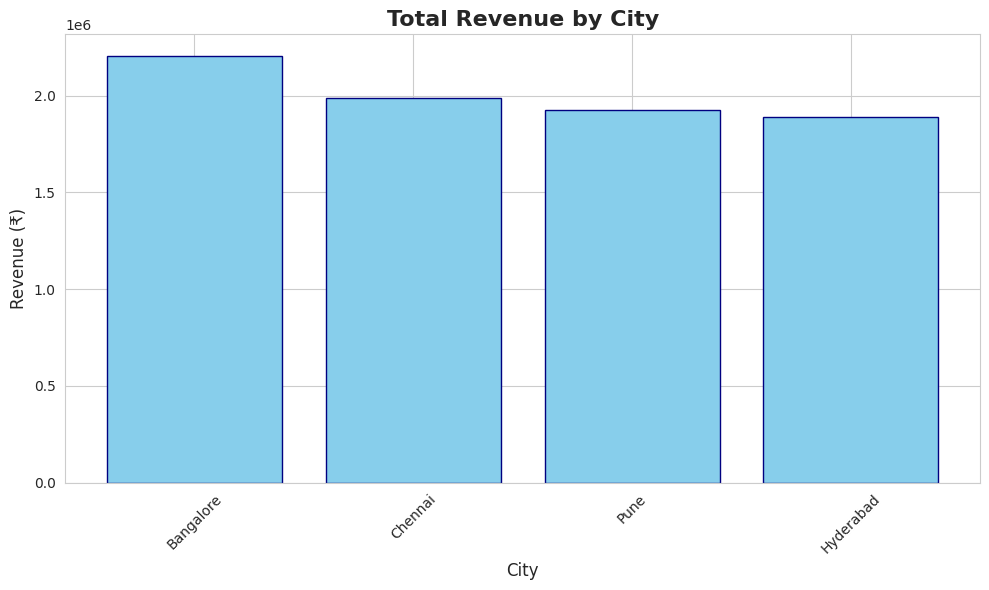

In [67]:
# Visualization 1: City Revenue
plt.figure(figsize=(10, 6))
plt.bar(city_df['city'], city_df['total_revenue'], color='skyblue', edgecolor='navy')
plt.title('Total Revenue by City', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

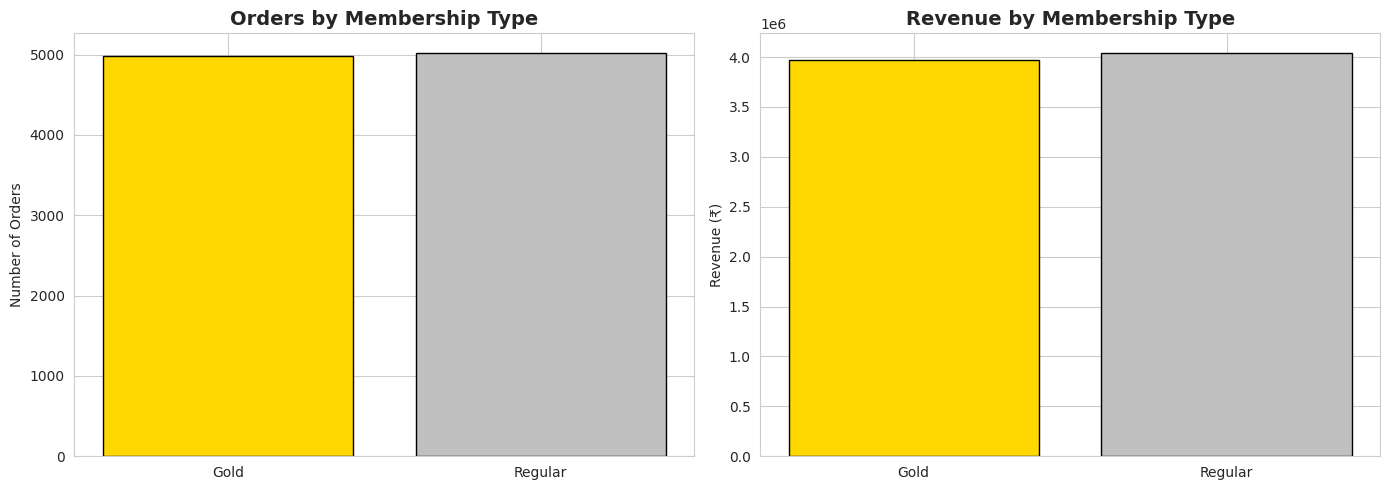

In [68]:
# Visualization 2: Membership Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders comparison
axes[0].bar(membership_df['membership'], membership_df['orders'],
            color=['gold', 'silver'], edgecolor='black')
axes[0].set_title('Orders by Membership Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Revenue comparison
axes[1].bar(membership_df['membership'], membership_df['total_revenue'],
            color=['gold', 'silver'], edgecolor='black')
axes[1].set_title('Revenue by Membership Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue (₹)')

plt.tight_layout()
plt.show()

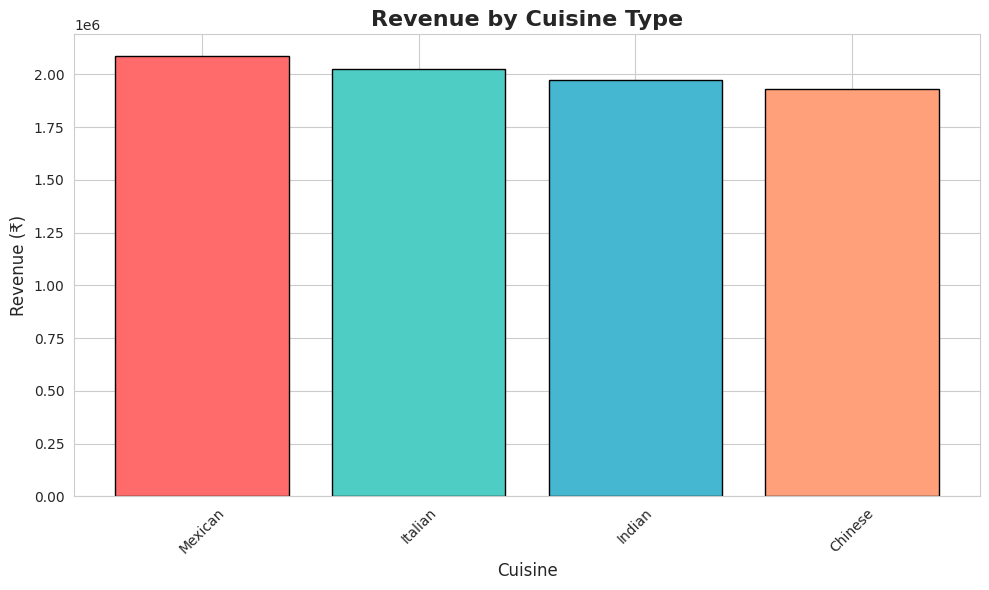

In [69]:
# Visualization 3: Cuisine Performance
plt.figure(figsize=(10, 6))
plt.bar(cuisine_df['cuisine'], cuisine_df['revenue'],
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], edgecolor='black')
plt.title('Revenue by Cuisine Type', fontsize=16, fontweight='bold')
plt.xlabel('Cuisine', fontsize=12)
plt.ylabel('Revenue (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
# Export final dataset to CSV
print("Exporting final dataset...")

cursor.execute("SELECT * FROM final_food_delivery_dataset")
results = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]

final_df = pd.DataFrame(results, columns=columns)
final_df.to_csv('/content/final_food_delivery_dataset.csv', index=False)

print(f" Exported {len(final_df):,} records to CSV")
print(f"\nFile location: /content/final_food_delivery_dataset.csv")
print(f"File size: {final_df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

Exporting final dataset...
✓ Exported 10,000 records to CSV

File location: /content/final_food_delivery_dataset.csv
File size: 5.66 MB


In [71]:
# Download the final dataset
files.download('/content/final_food_delivery_dataset.csv')
print(" Download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started!


In [72]:
# Close connection
cursor.close()
connection.close()
print("\n Database connection closed")



 Database connection closed
